# Text embeddings

A text embedding is a high-dimensional latent space where words or phrases are represented as vectors. In this notebook we will determine the vectors for a couple of words. For visualization purposes, we will apply principal-component-analysis to these vectors and display the relationship of the words in two-dimensional space.

We use a [llama-index](https://github.com/run-llama/llama_index) library, which needs to be installed first:
```
pip install llama-index-embeddings-huggingface
```

In [1]:
import openai
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

This helper functions will serve us to determine the vector for each word / text.

In [3]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(model_name="intfloat/multilingual-e5-large-instruct")

def embed(text):
    return embed_model._get_text_embedding(text)

In [4]:
vector = embed("Hello world")
vector[:3]

[0.0052167209796607494, 0.025283105671405792, 0.00728016160428524]

In [5]:
len(vector)

1024

In [6]:
words = [ "dog", "cat", "hamster", "guinea pig", "pet", "microscope", "compute", "cloud", "high-performance-computing"]

# Example of input dictionary
object_coords = {word: embed(word) for word in words}

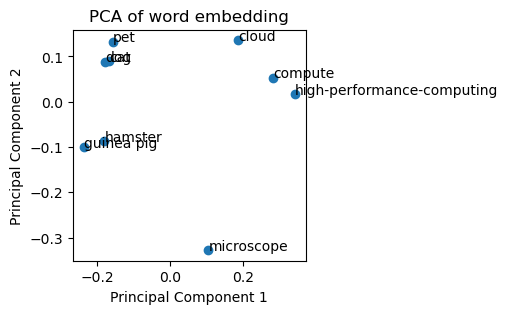

In [7]:
# Extract names and numerical lists
names = list(object_coords.keys())
data_matrix = np.array(list(object_coords.values()))

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
transformed_data = pca.fit_transform(data_matrix)

# Create scatter plot
plt.figure(figsize=(3, 3))
plt.scatter(transformed_data[:, 0], transformed_data[:, 1])

# Annotate data points with names
for i, name in enumerate(names):
    plt.annotate(name, (transformed_data[i, 0], transformed_data[i, 1]))

plt.title('PCA of word embedding')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Exercise
Draw an embedding for words from your scientific domain, e.g. "segmentation", "thresholding", "otsu", "deep learning", "segment anything", "feature extraction".
* Could you predict how the words are placed in this space? 
* Draw the same embedding again - is the visualization repeatable? 
* Change the order of the words in the list. Would you expect the visualization to change?
* Add words such as  "banana", "apple", "orange". Could you predict the view?

Also try with a different embedding such as [BAAI/bge-base-en-v1.5](https://huggingface.co/BAAI/bge-base-en-v1.5).